In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', 500)

In [3]:
df = pd.read_csv("C:/Users/aksha/Documents/data/Loan_default.csv")

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.shape

(255347, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


# Describing the data 
### The Loan default data contains 255,347 cases with 24 key features. These features are:-
### 1) LoanID: A unique identifier for each loan
### 2) Age: The age of the borrower
### 3) Income: The annual income of the borrower 
### 4) LoanAmount: - The amount of money being borrowed
### 5) Credit Score: The Credit Score of the borrower
### 6) Months Employed: The number of months the borrower has been employed
### 7) NumCreditLines: The number of credit lines the borrower has open
### 8) InterestRate: The rate of Interest 
### 9) LoanTerm: The term length of the loan in months
### 10) DTIRatio: Debt-To-Income Ratio
### 11) Education: Education level of the borrower
### 12) EmploymentType: Employment type of the borrower (employed/self-employed/unemployed)
### 13) MaritalStatus: marital status of the borrower (single/married/divorced)
### 14) HasMortgage: whether the borrower has mortgage (yes/no)
### 15) HasDependents: whether the borrower has dependents (yes/no)
### 16) LoanPurpose: The purpose of the Loan (Home, Auto, Educational, Personal, Business)
### 17) HasCoSigner: whether the borrower has a co-signer (yes/no)
### 18) Default: whether the borrower has defaulted the loan or not (Yes/No)

In [8]:
df.groupby('Default')['Income'].idxmax()

Default
0    183400
1     18289
Name: Income, dtype: int64

In [9]:
df.iloc[df.groupby('Default')['Income'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
183400,ZQGVAT7T79,59,149999,87625,344,98,2,2.58,12,0.72,Bachelor's,Part-time,Single,No,No,Business,No,0
18289,K4BL6ZJEYB,39,149995,111877,474,20,1,9.96,12,0.35,Master's,Self-employed,Married,Yes,No,Home,No,1


In [10]:
df.iloc[df.groupby('Default')['Age'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
1997,QM5E2KBYVM,69,17120,176950,597,25,1,22.88,48,0.19,High School,Part-time,Married,Yes,No,Other,No,1


In [11]:
df.iloc[df.groupby('Default')['Income'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
8908,QOFPX1XIJE,68,15000,246909,765,24,2,8.81,24,0.81,PhD,Unemployed,Divorced,No,Yes,Education,No,0
203871,1OZFF0Y79S,19,15004,156589,303,68,3,14.09,48,0.41,Bachelor's,Self-employed,Divorced,Yes,No,Education,Yes,1


In [12]:
df.iloc[df.groupby('Default')['Age'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
101,UBVMQUAJS3,18,148123,243038,734,105,4,10.29,60,0.71,High School,Self-employed,Divorced,Yes,No,Home,No,0
491,P5LXL995UO,18,50554,97542,806,19,3,11.42,48,0.61,Master's,Unemployed,Married,Yes,Yes,Home,No,1


In [13]:
df.sort_values(by='Income', ascending=False).head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
183400,ZQGVAT7T79,59,149999,87625,344,98,2,2.58,12,0.72,Bachelor's,Part-time,Single,No,No,Business,No,0
252244,VOXXF484TC,29,149999,167765,387,68,3,10.70,36,0.83,High School,Part-time,Single,Yes,Yes,Other,No,0
203080,DFK5DI3QM7,66,149997,189088,395,91,2,22.37,48,0.14,Bachelor's,Self-employed,Divorced,Yes,Yes,Other,No,0
8905,W3UWERC20V,55,149997,112151,466,102,1,10.29,48,0.77,PhD,Unemployed,Married,Yes,Yes,Other,No,0
80940,5HJ6IOCM5O,19,149996,193267,748,67,2,3.78,12,0.57,PhD,Self-employed,Divorced,No,No,Business,No,0


In [14]:
df.sort_values(by='LoanAmount', ascending=False).head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
20256,BZ6O5YSSA8,37,114264,249999,598,106,3,8.47,36,0.71,High School,Full-time,Single,Yes,No,Business,Yes,0
232552,TGYZ4AXW7H,52,140430,249998,484,80,4,13.67,24,0.76,PhD,Full-time,Single,Yes,Yes,Education,Yes,0
206804,VIS6H9YBJM,44,76674,249997,304,87,1,12.12,48,0.34,Bachelor's,Full-time,Married,No,No,Other,Yes,0
239262,7OV9HHSV62,26,137747,249996,451,47,4,22.04,36,0.72,PhD,Full-time,Married,Yes,Yes,Home,No,0
135381,RXGEJP7QPL,65,23329,249993,684,4,1,9.35,12,0.47,High School,Self-employed,Divorced,No,Yes,Business,Yes,1


In [15]:
df.iloc[df.groupby('Default')['LoanAmount'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
20256,BZ6O5YSSA8,37,114264,249999,598,106,3,8.47,36,0.71,High School,Full-time,Single,Yes,No,Business,Yes,0
135381,RXGEJP7QPL,65,23329,249993,684,4,1,9.35,12,0.47,High School,Self-employed,Divorced,No,Yes,Business,Yes,1


In [16]:
df.iloc[df.groupby('Default')['LoanAmount'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
148043,4PPBDEB2NT,36,106933,5001,656,98,1,3.30,24,0.86,Bachelor's,Part-time,Single,Yes,Yes,Education,No,0
169381,9AO69WP1G5,38,99437,5000,538,89,3,16.96,12,0.45,Master's,Self-employed,Married,Yes,Yes,Home,Yes,1


In [17]:
df.sort_values(by='CreditScore', ascending=False).head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
6869,GXRIQV4E29,59,82313,197970,849,76,4,8.80,24,0.72,Master's,Unemployed,Divorced,No,No,Business,Yes,0
222262,19DM82EBAH,56,56200,242029,849,107,2,22.02,24,0.38,High School,Unemployed,Single,Yes,No,Education,No,0
149299,4GXNK490K5,56,71222,143619,849,110,4,14.51,24,0.20,High School,Self-employed,Divorced,No,No,Other,No,0
101325,Z1IPJYI68L,36,127462,29978,849,5,3,21.19,36,0.62,Master's,Unemployed,Single,No,No,Other,No,0
244971,Z7A3D7WV03,55,72634,9152,849,20,4,24.46,48,0.57,Master's,Self-employed,Married,Yes,Yes,Business,No,0


In [18]:
df.sort_values(by='MonthsEmployed', ascending=False).head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
170534,7CWHSUA9ME,22,15208,99172,344,119,2,24.68,48,0.33,Master's,Full-time,Married,No,No,Auto,Yes,1
5787,BFK01HM2Z7,43,100864,49764,819,119,3,19.61,12,0.74,High School,Self-employed,Single,Yes,No,Education,Yes,0
79407,GM8RVBZX0X,19,98773,111109,838,119,1,12.36,48,0.14,High School,Self-employed,Single,Yes,No,Business,No,0
145826,Z7F74JU2E2,59,42017,204271,693,119,2,2.18,12,0.39,PhD,Self-employed,Married,Yes,No,Education,No,0
198419,F5GGJT794E,69,133378,77399,570,119,3,9.66,24,0.76,Bachelor's,Unemployed,Married,No,Yes,Education,No,0


In [19]:
df.iloc[df.groupby('Default')['MonthsEmployed'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
95,4JQAOGI6A8,42,30200,182868,517,119,3,16.87,24,0.51,Bachelor's,Part-time,Single,Yes,Yes,Auto,Yes,0
18,O1IKKLC69B,19,40718,78515,319,119,2,14.00,24,0.17,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1


In [20]:
df.iloc[df.groupby('Default')['MonthsEmployed'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
1252,Q7Z5NWYBCZ,23,113761,109291,669,0,2,24.30,36,0.19,PhD,Unemployed,Divorced,No,No,Education,Yes,1


In [21]:
df.iloc[df.groupby('Default')['CreditScore'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
693,92A029ST5W,36,107236,11586,300,60,2,7.74,24,0.83,Bachelor's,Self-employed,Single,Yes,Yes,Auto,No,0
2561,CIS1M4Q4DN,20,118332,211028,300,6,3,15.46,36,0.74,High School,Part-time,Single,No,No,Education,Yes,1


In [22]:
df.iloc[df.groupby('Default')['CreditScore'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
254,U6PDHQHG5M,65,41931,5769,849,7,2,7.70,60,0.68,PhD,Self-employed,Divorced,No,No,Other,Yes,0
2410,F8G8R51X0J,20,92491,148929,849,47,2,8.59,12,0.12,PhD,Self-employed,Married,Yes,No,Education,No,1


In [23]:
df.iloc[df.groupby('Default')['InterestRate'].idxmax()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
3266,4UPMWRF1AE,49,135749,130449,727,18,2,25.0,60,0.25,Master's,Self-employed,Married,Yes,No,Education,No,0
28417,9278LBEK28,24,142807,184189,573,74,3,25.0,24,0.23,Bachelor's,Unemployed,Single,No,Yes,Auto,Yes,1


In [24]:
df.iloc[df.groupby('Default')['InterestRate'].idxmin()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
5039,513BEJOC3I,56,92291,75152,442,3,3,2.0,60,0.80,Bachelor's,Full-time,Single,No,No,Auto,No,0
17333,YSIH62QDW2,52,70769,30399,641,7,2,2.0,48,0.22,High School,Part-time,Married,No,Yes,Education,Yes,1


In [25]:
num_cols = df.select_dtypes(exclude='object').columns.tolist()

In [26]:
for col in num_cols:
    print(f"Mean for {col} is {df[col].mean()}")
    print(f"Median for {col} is {df[col].median()}")
    print(f"Standard deviation for {col} is {df[col].std()}")
    print(f"25% of {col} is {df[col].quantile(0.25)}")
    print(f"50% of {col} is {df[col].quantile(0.50)}")
    print(f"75% of {col} is {df[col].quantile(0.75)}")
    print(f"100% of {col} is {df[col].quantile(1.0)}")

Mean for Age is 43.498306226429136
Median for Age is 43.0
Standard deviation for Age is 14.990258418709589
25% of Age is 31.0
50% of Age is 43.0
75% of Age is 56.0
100% of Age is 69.0
Mean for Income is 82499.30459727351
Median for Income is 82466.0
Standard deviation for Income is 38963.013729378144
25% of Income is 48825.5
50% of Income is 82466.0
75% of Income is 116219.0
100% of Income is 149999.0
Mean for LoanAmount is 127578.86551242035
Median for LoanAmount is 127556.0
Standard deviation for LoanAmount is 70840.70614150059
25% of LoanAmount is 66156.0
50% of LoanAmount is 127556.0
75% of LoanAmount is 188985.0
100% of LoanAmount is 249999.0
Mean for CreditScore is 574.2643461642392
Median for CreditScore is 574.0
Standard deviation for CreditScore is 158.9038665949753
25% of CreditScore is 437.0
50% of CreditScore is 574.0
75% of CreditScore is 712.0
100% of CreditScore is 849.0
Mean for MonthsEmployed is 59.541976212761455
Median for MonthsEmployed is 60.0
Standard deviation fo

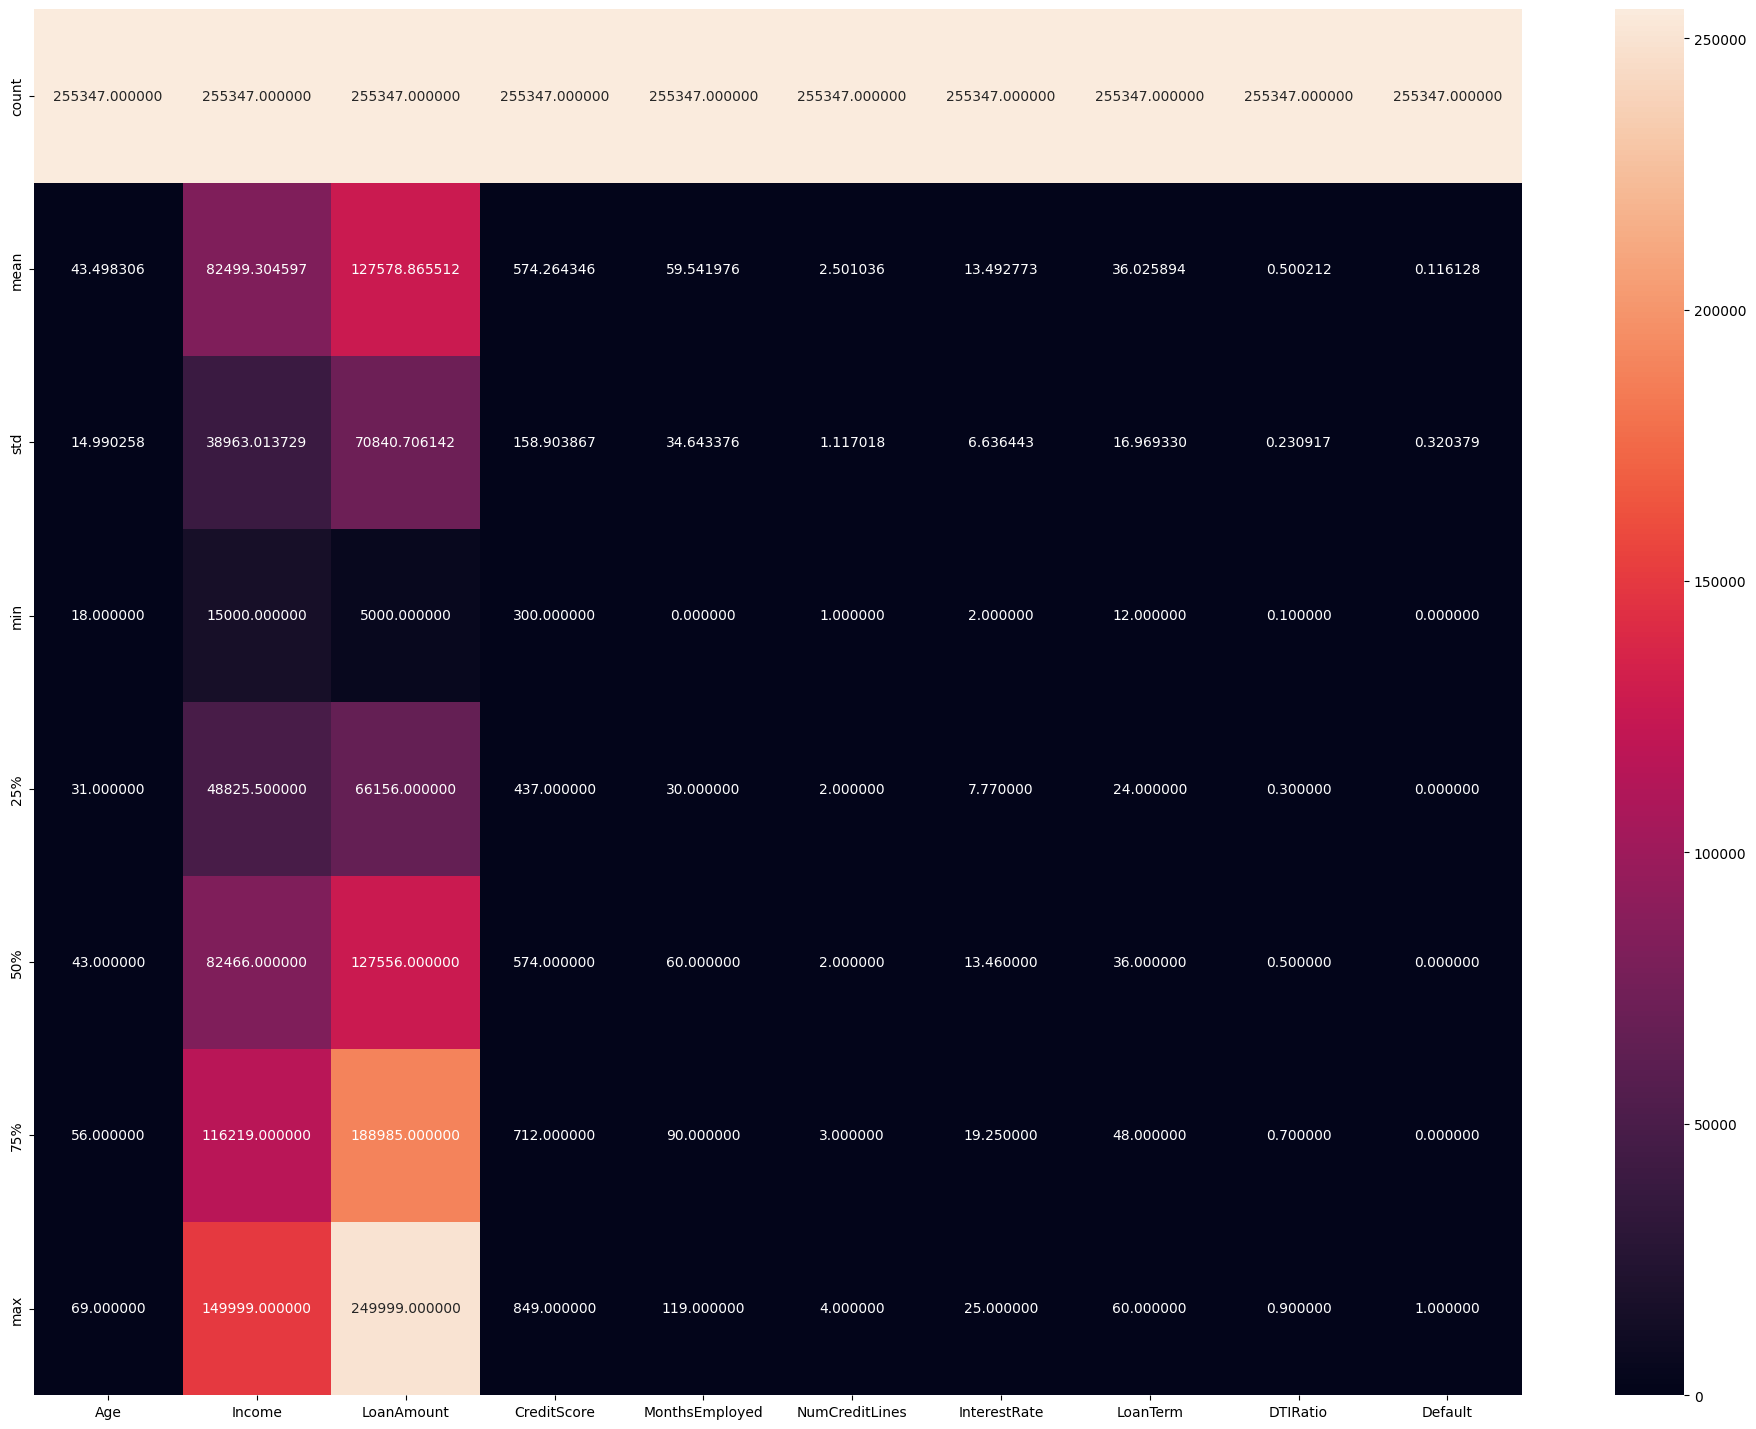

In [27]:
plt.figure(figsize=(24,18))
sns.heatmap(df.describe(), annot=True, fmt='f')
plt.show()

In [28]:
df.groupby('Income')['Default'].mean().idxmax(), df.groupby('Income')['Default'].mean().idxmin()

(15018, 15000)

In [29]:
labels = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
df['Income_category'] = pd.qcut(df['Income'], q=4, labels = labels)

In [30]:
df.groupby('Income_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\9520243.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_category')['Default'].mean()*100


Income_category
Low Income             17.380203
Lower-Middle Income    10.537776
Upper-Middle Income     9.512994
High Income             9.020271
Name: Default, dtype: float64

In [31]:
labels = ['Lower Age', 'Lower-Middle Age', 'Upper-Middle Age', 'Higher Age']
df['Age_category'] = pd.qcut(df['Age'], q=4, labels = labels)

In [32]:
df.groupby('Age_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\4023161283.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_category')['Default'].mean()*100


Age_category
Lower Age           19.147259
Lower-Middle Age    12.883850
Upper-Middle Age     8.589168
Higher Age           5.360313
Name: Default, dtype: float64

In [33]:
labels = ['Lower Loan Amount', 'Lower-Middle Loan Amount', 'Upper-Middle Loan Amount', 'Higher Loan Amount']
df['LoanAmount_category'] = pd.qcut(df['LoanAmount'], q=4, labels = labels)

In [34]:
df.groupby('LoanAmount_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\1526041036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('LoanAmount_category')['Default'].mean()*100


LoanAmount_category
Lower Loan Amount            8.245872
Lower-Middle Loan Amount    10.248136
Upper-Middle Loan Amount    12.353531
Higher Loan Amount          15.603803
Name: Default, dtype: float64

In [35]:
labels = ['Lower Credit Score', 'Lower-Middle Credit Score', 'Upper-Middle Credit Score', 'Higher Credit Score']
df['CreditScore_category'] = pd.qcut(df['CreditScore'], q=4, labels = labels)

In [36]:
df.groupby('CreditScore_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\2895137410.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditScore_category')['Default'].mean()*100


CreditScore_category
Lower Credit Score           13.055815
Lower-Middle Credit Score    11.894425
Upper-Middle Credit Score    11.290222
Higher Credit Score          10.197141
Name: Default, dtype: float64

In [37]:
labels = ['Lower Months Employed', 'Lower-Middle Months Employed', 'Upper-Middle Months Employed', 'Higher Months Employed']
df['MonthsEmployed_category'] = pd.qcut(df['MonthsEmployed'], q=4, labels = labels)

In [38]:
df.groupby('MonthsEmployed_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\2614520967.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('MonthsEmployed_category')['Default'].mean()*100


MonthsEmployed_category
Lower Months Employed           16.033576
Lower-Middle Months Employed    12.361921
Upper-Middle Months Employed     9.954318
Higher Months Employed           7.847320
Name: Default, dtype: float64

In [39]:
df.groupby('LoanTerm')['Default'].mean()*100

LoanTerm
12    11.617638
24    11.607755
36    11.568516
48    11.574092
60    11.696055
Name: Default, dtype: float64

In [40]:
labels = ['Lower DTI', 'Lower-Middle DTI', 'Upper-Middle DTI', 'Higher DTI']
df['DTIRatio_category'] = pd.qcut(df['DTIRatio'], q=4, labels = labels)

In [41]:
df.groupby('DTIRatio_category')['Default'].mean()*100

C:\Users\aksha\AppData\Local\Temp\ipykernel_7448\2232486530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('DTIRatio_category')['Default'].mean()*100


DTIRatio_category
Lower DTI           10.659331
Lower-Middle DTI    11.535095
Upper-Middle DTI    11.987896
Higher DTI          12.306730
Name: Default, dtype: float64

<Axes: xlabel='Default', ylabel='EmploymentType'>

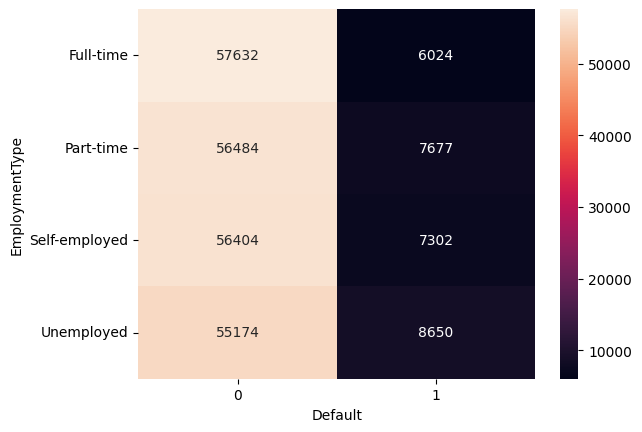

In [42]:
sns.heatmap(pd.crosstab(df['EmploymentType'], df['Default']), annot=True, fmt='d')

<Axes: xlabel='Default', ylabel='Education'>

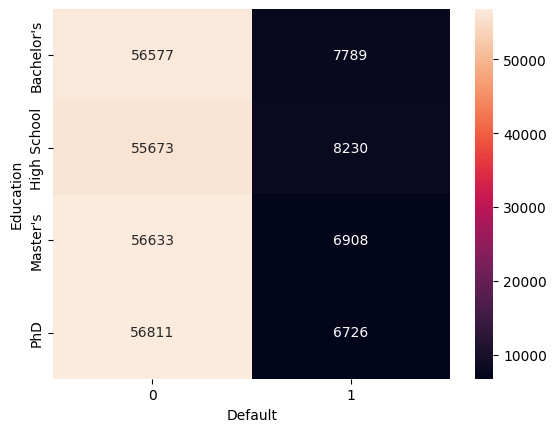

In [43]:
sns.heatmap(pd.crosstab(df['Education'], df['Default']), annot=True, fmt='d')

<Axes: xlabel='Default', ylabel='HasMortgage'>

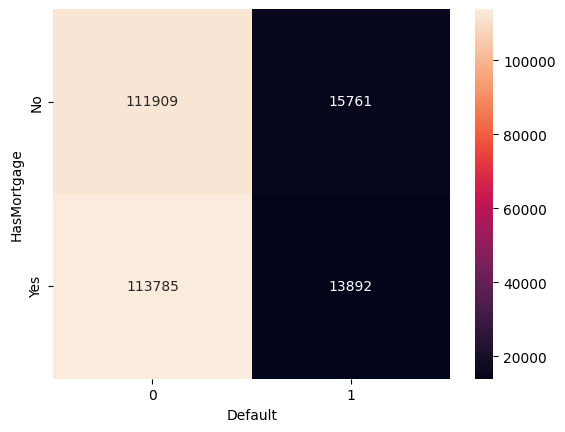

In [44]:
sns.heatmap(pd.crosstab(df['HasMortgage'], df['Default']), annot=True, fmt='d')

<Axes: xlabel='Default', ylabel='HasCoSigner'>

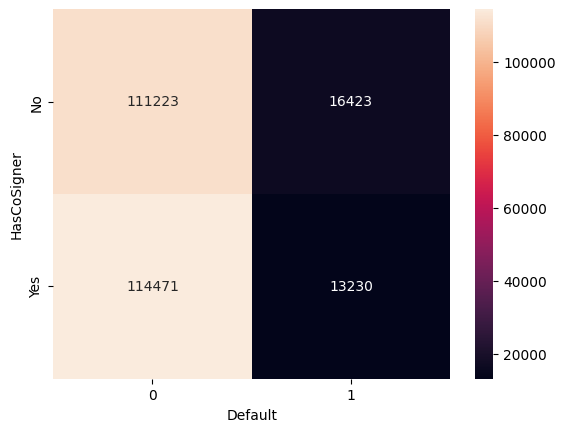

In [45]:
sns.heatmap(pd.crosstab(df['HasCoSigner'], df['Default']), annot=True, fmt='d')

<Axes: xlabel='Default', ylabel='MaritalStatus'>

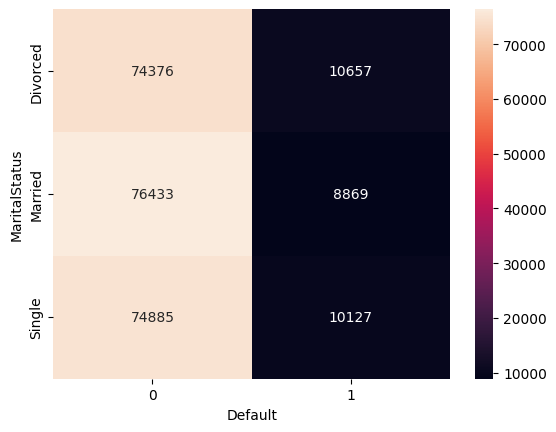

In [46]:
sns.heatmap(pd.crosstab(df['MaritalStatus'], df['Default']), annot=True, fmt='d')

<Axes: xlabel='Default', ylabel='LoanPurpose'>

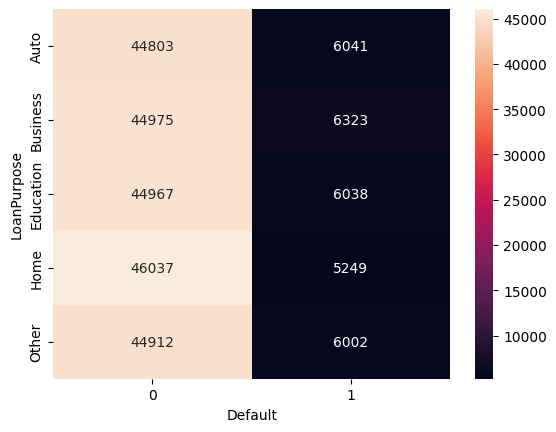

In [47]:
sns.heatmap(pd.crosstab(df['LoanPurpose'], df['Default']), annot=True, fmt='d')

In [48]:
df.Default.value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [49]:
df.Default.value_counts(normalize=True)*100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

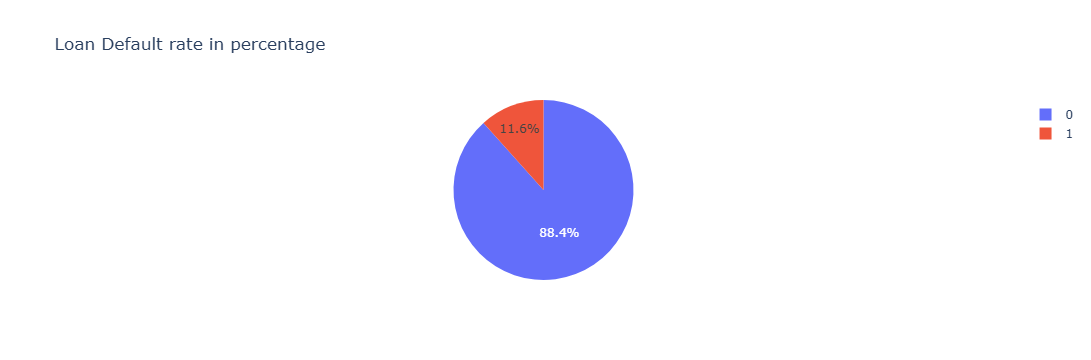

In [50]:
import plotly.express as px
px.pie(data_frame=df, names='Default', hover_data='Default', title='Loan Default rate in percentage')

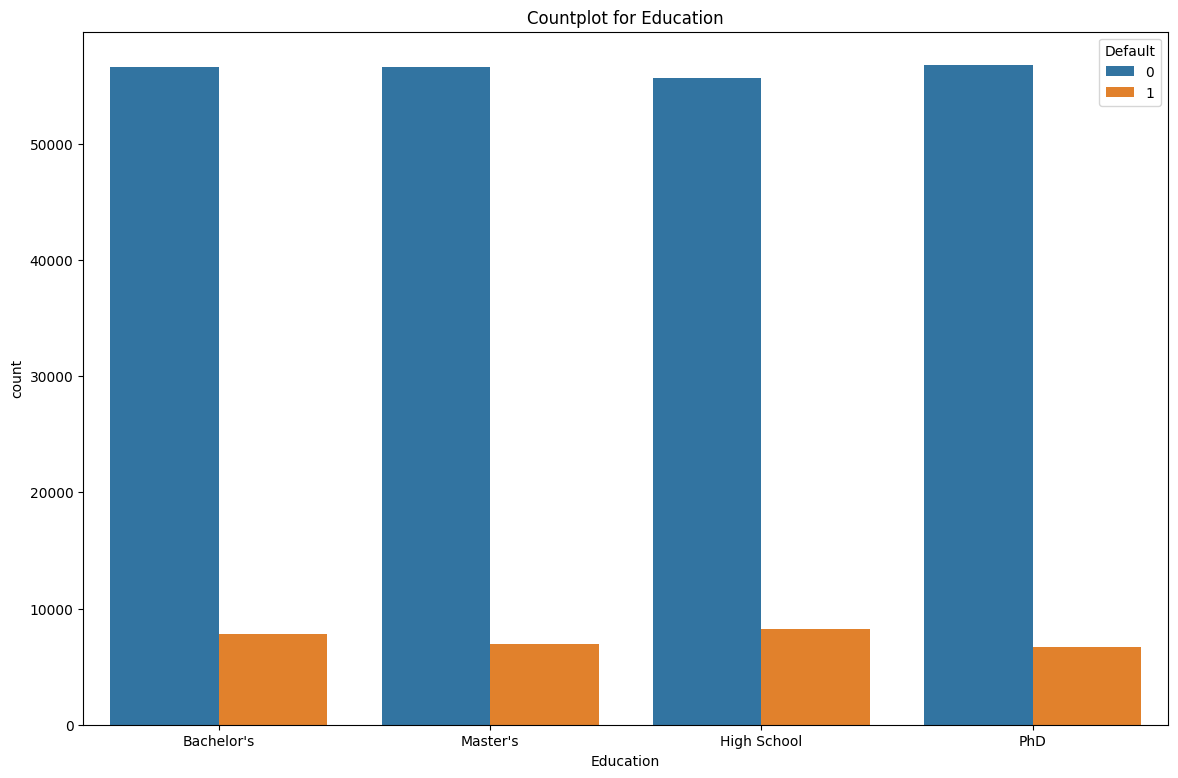

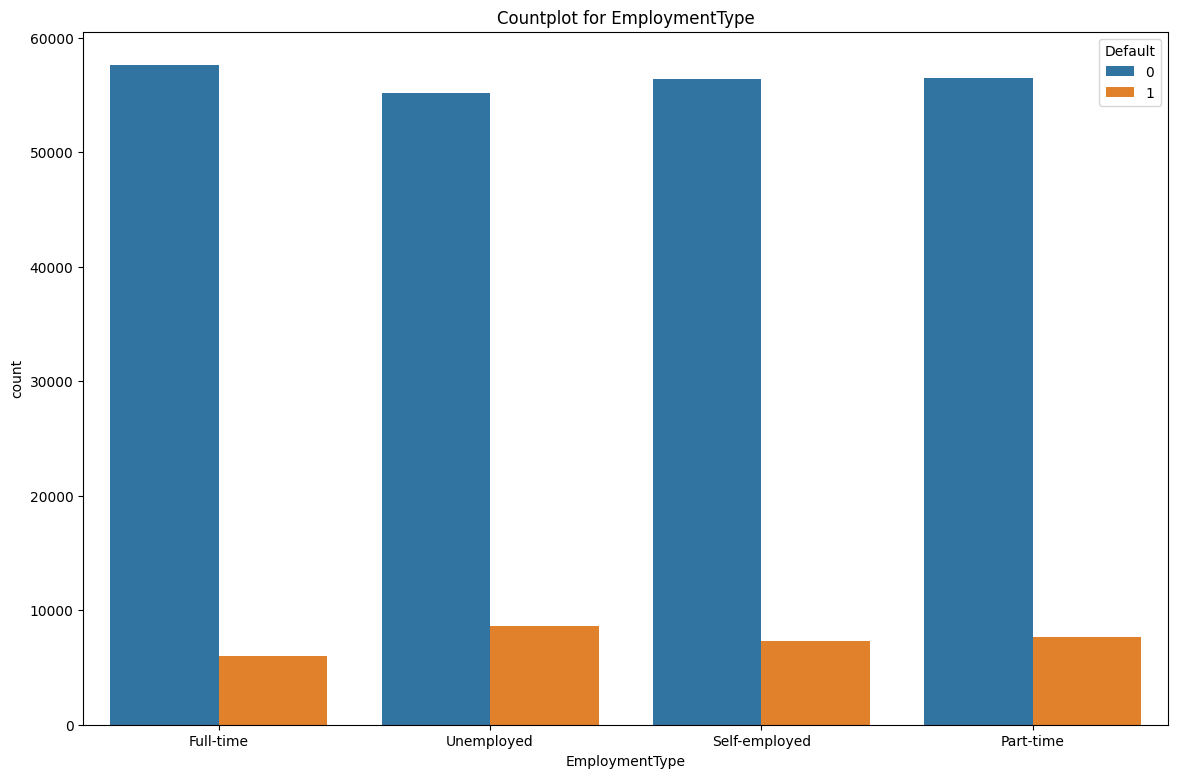

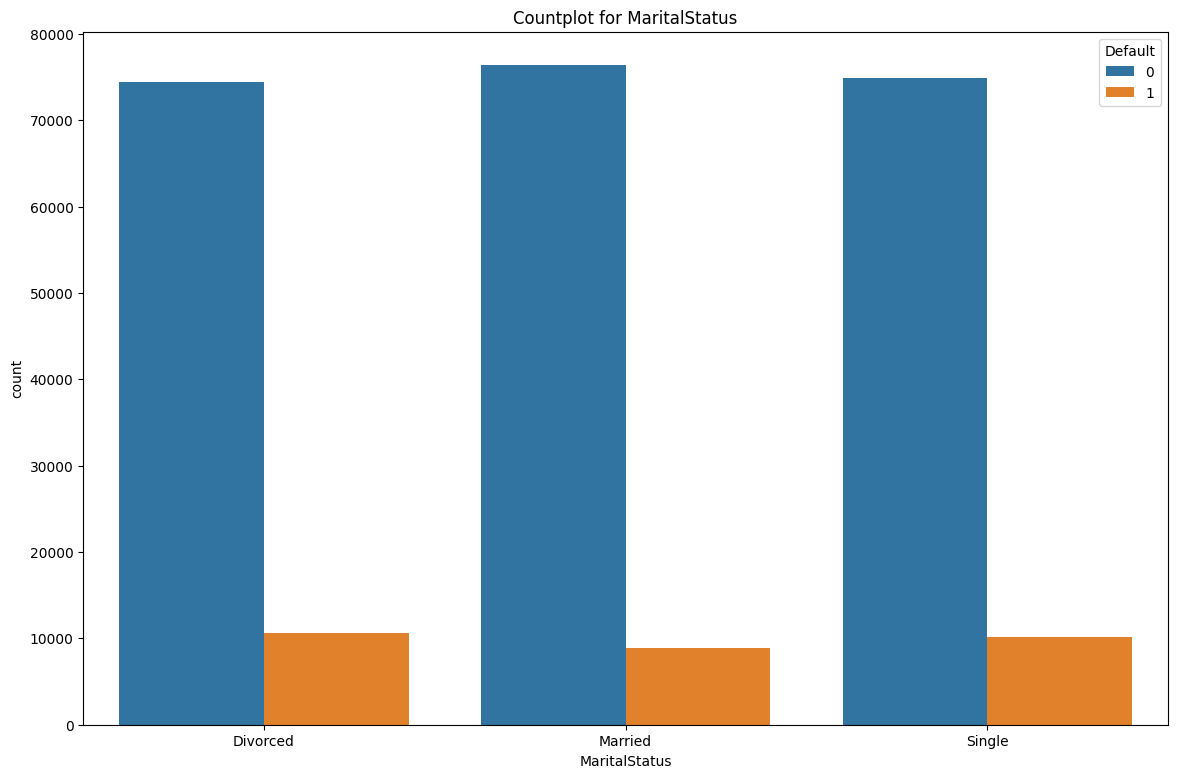

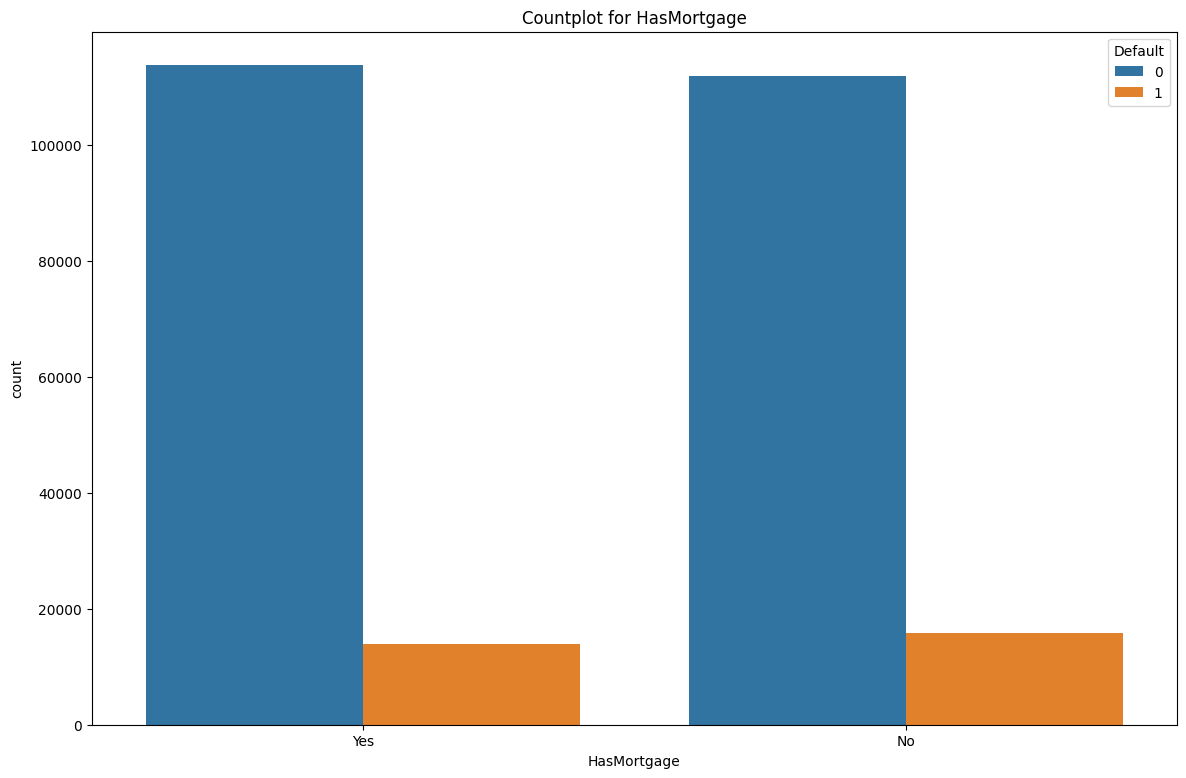

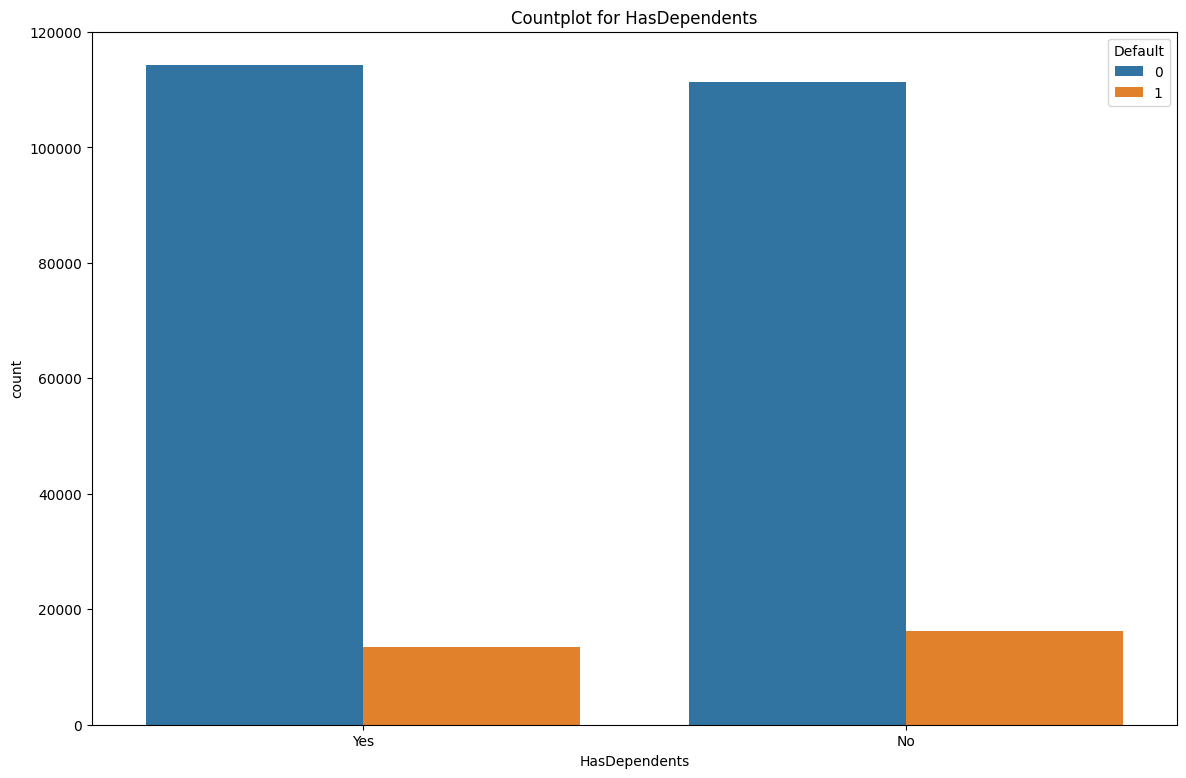

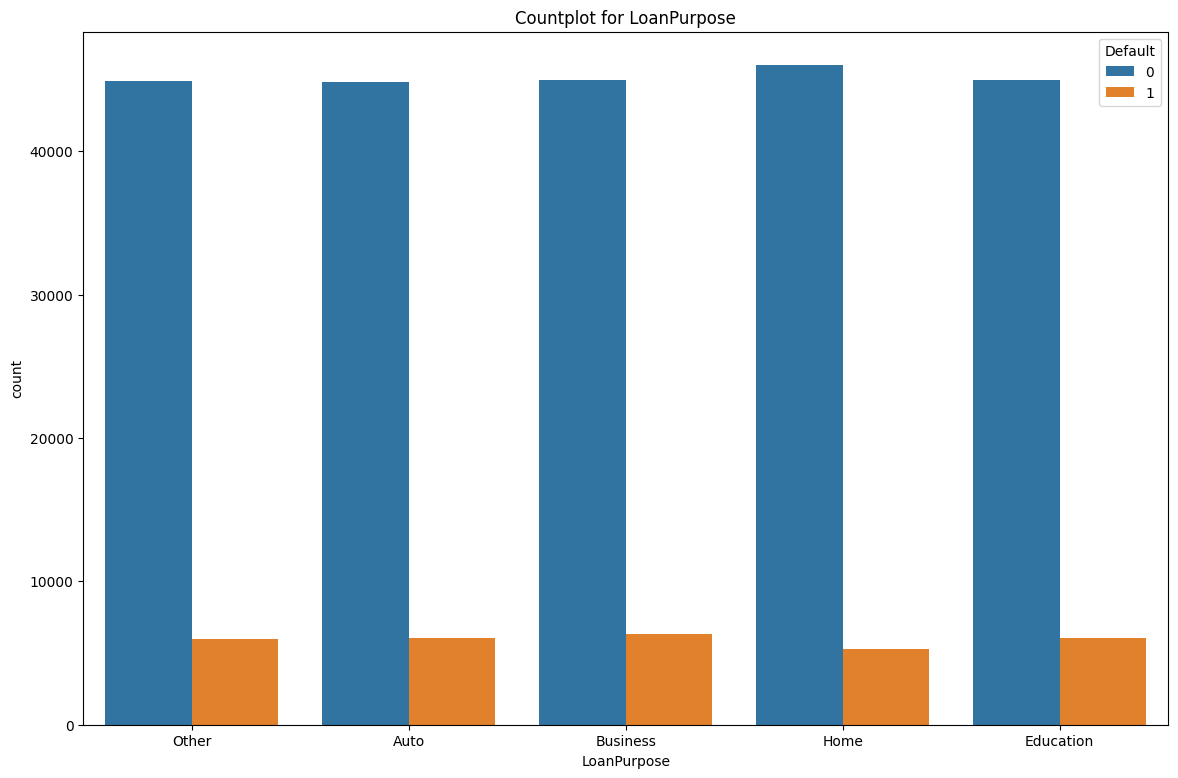

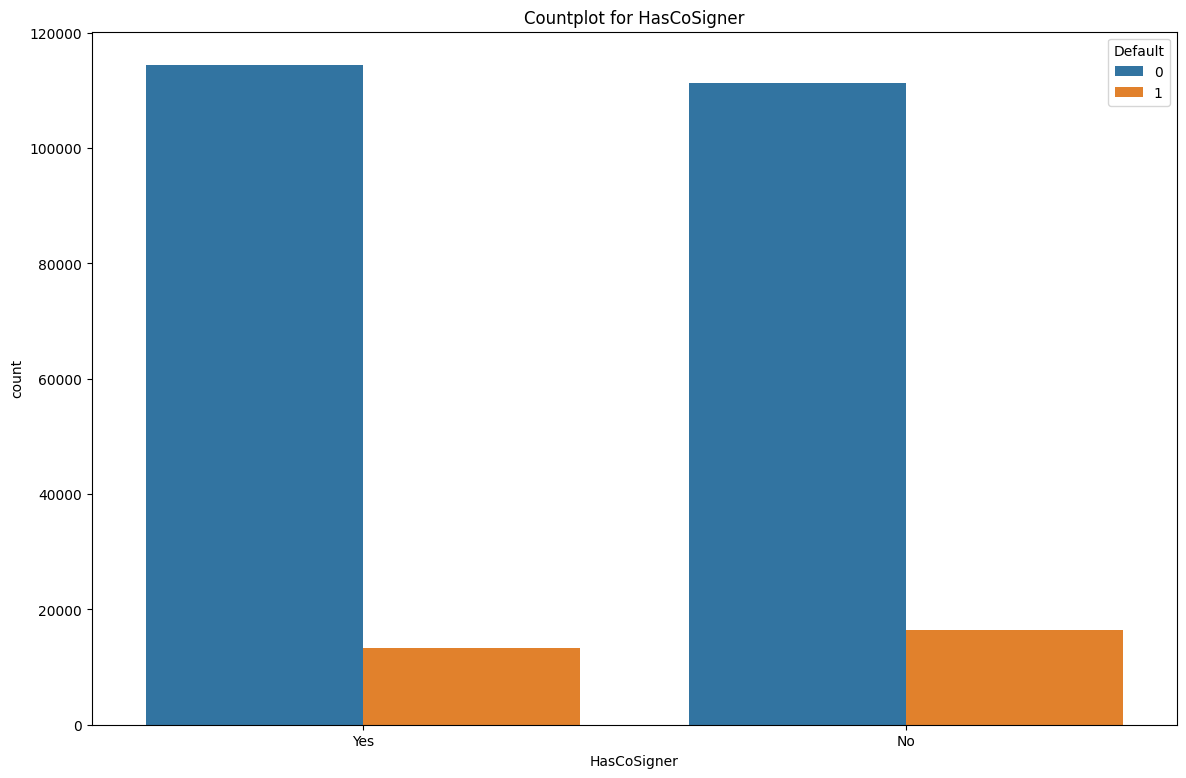

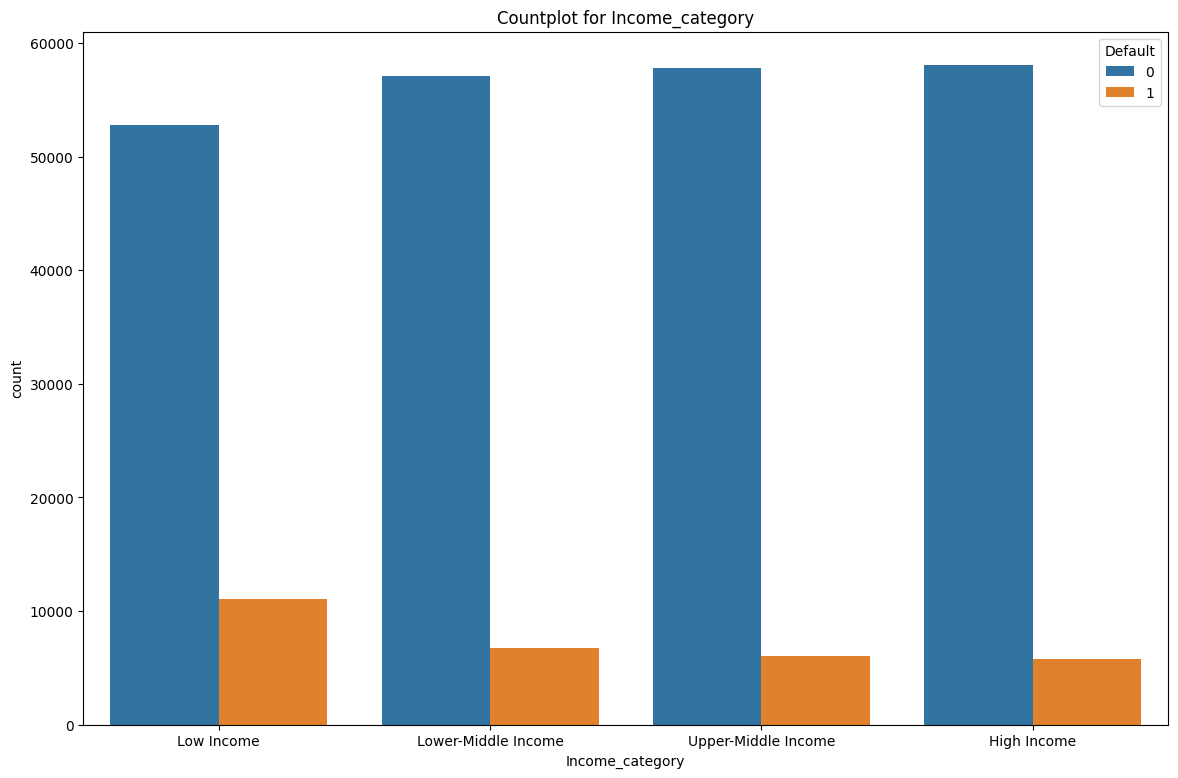

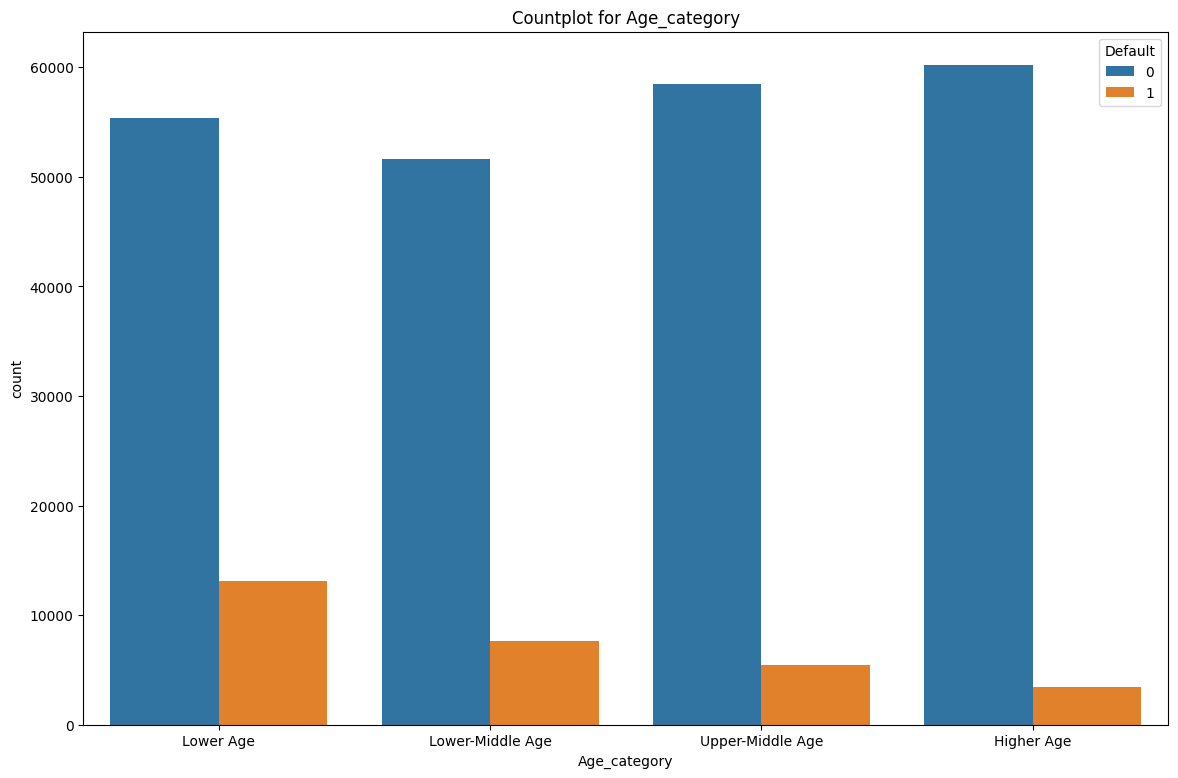

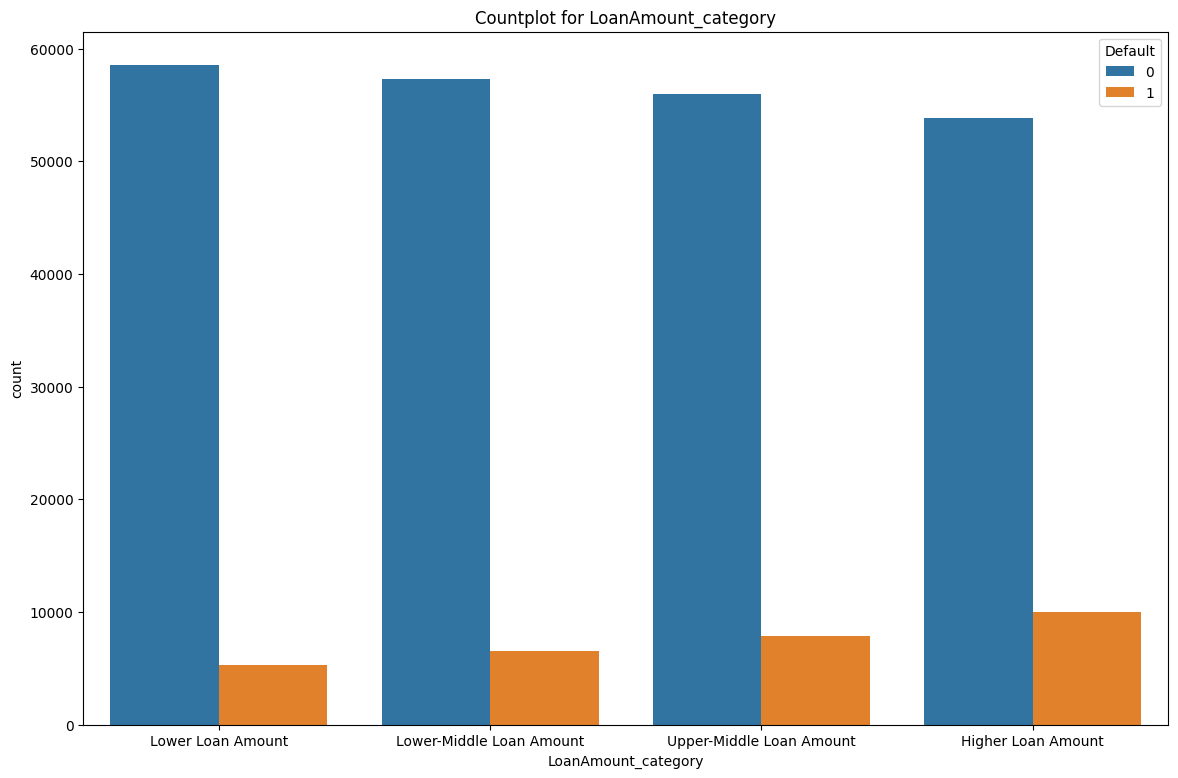

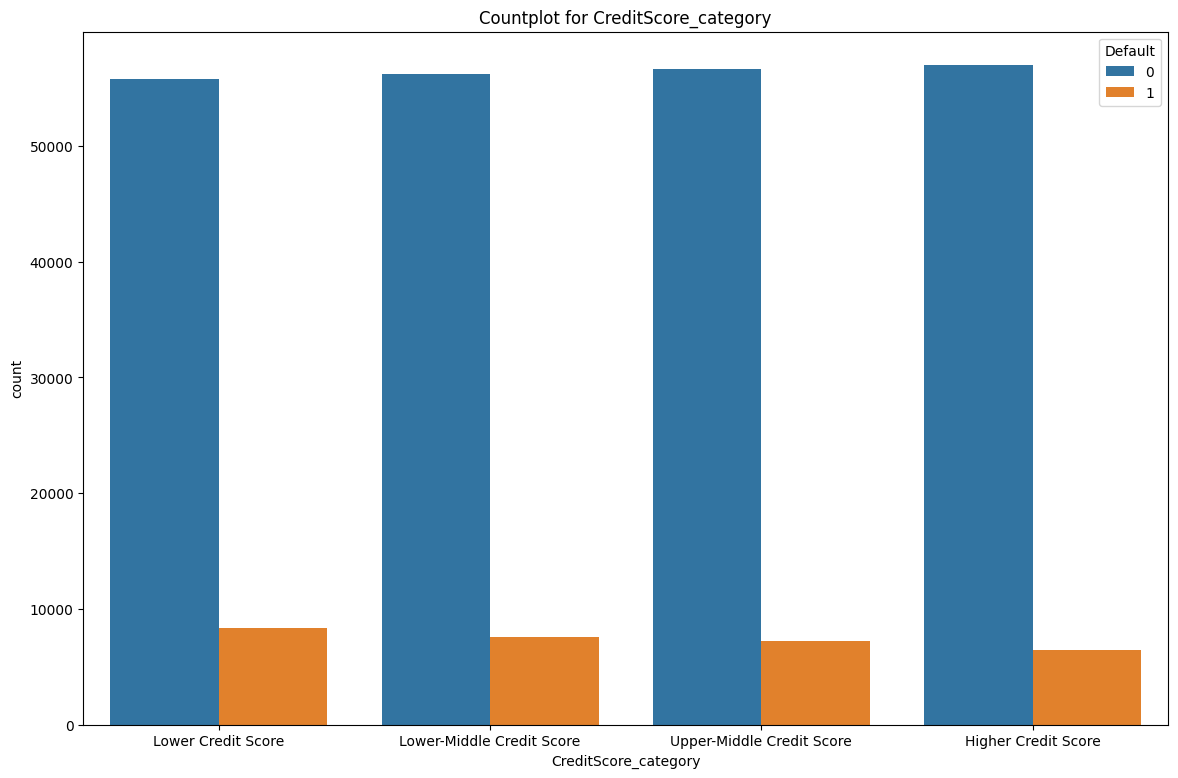

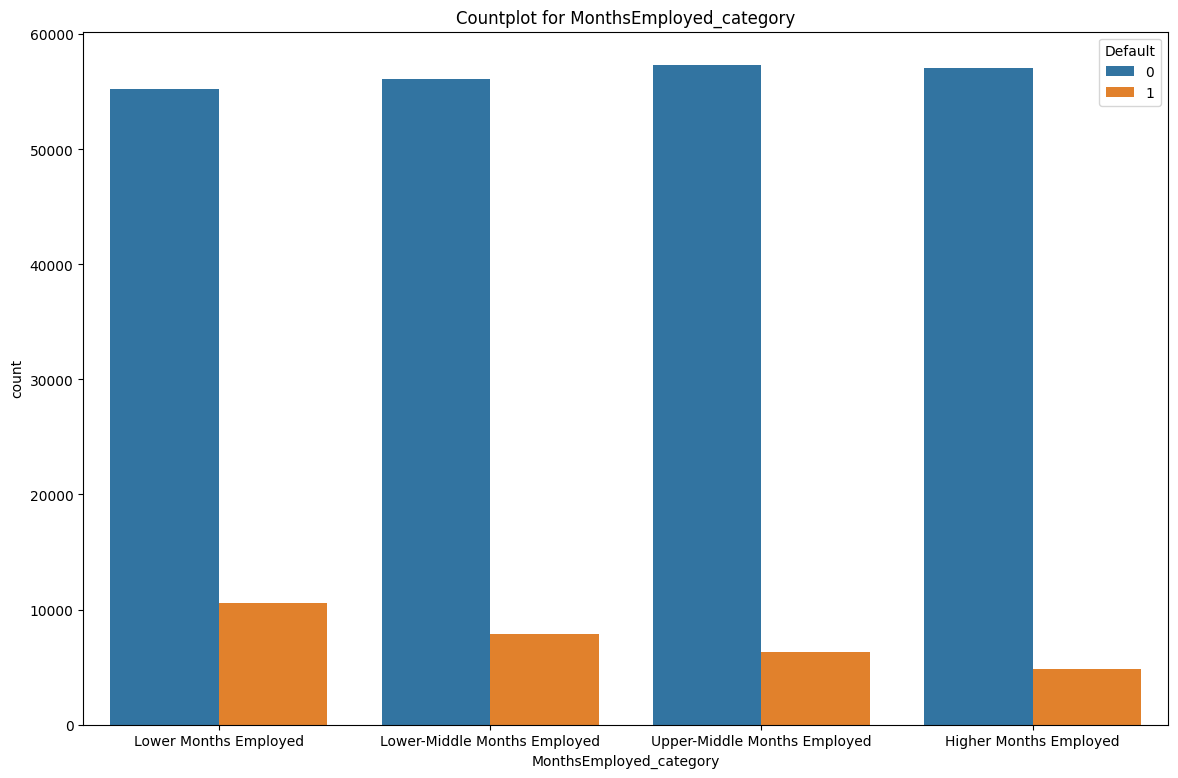

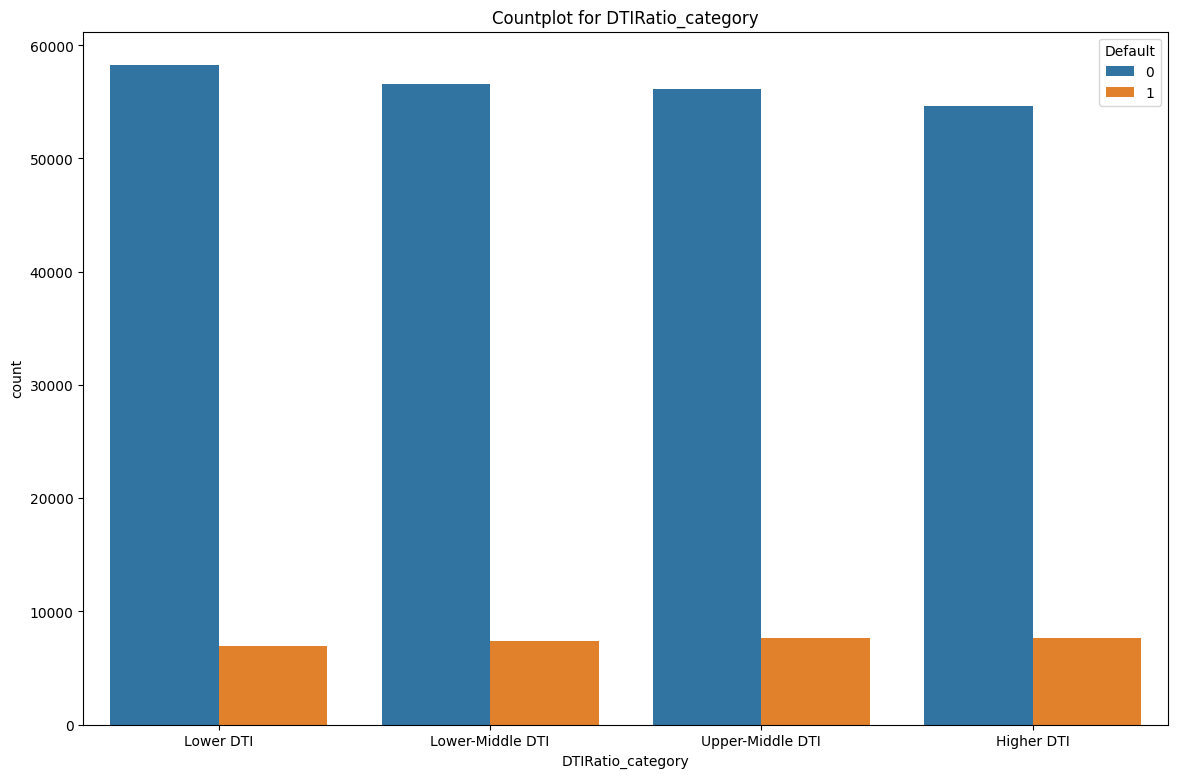

In [55]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('LoanID')
for col in cat_cols:
    plt.figure(figsize=(14, 9))
    sns.countplot(data=df, x=col, hue='Default')
    plt.title(f'Countplot for {col}')
    plt.show()

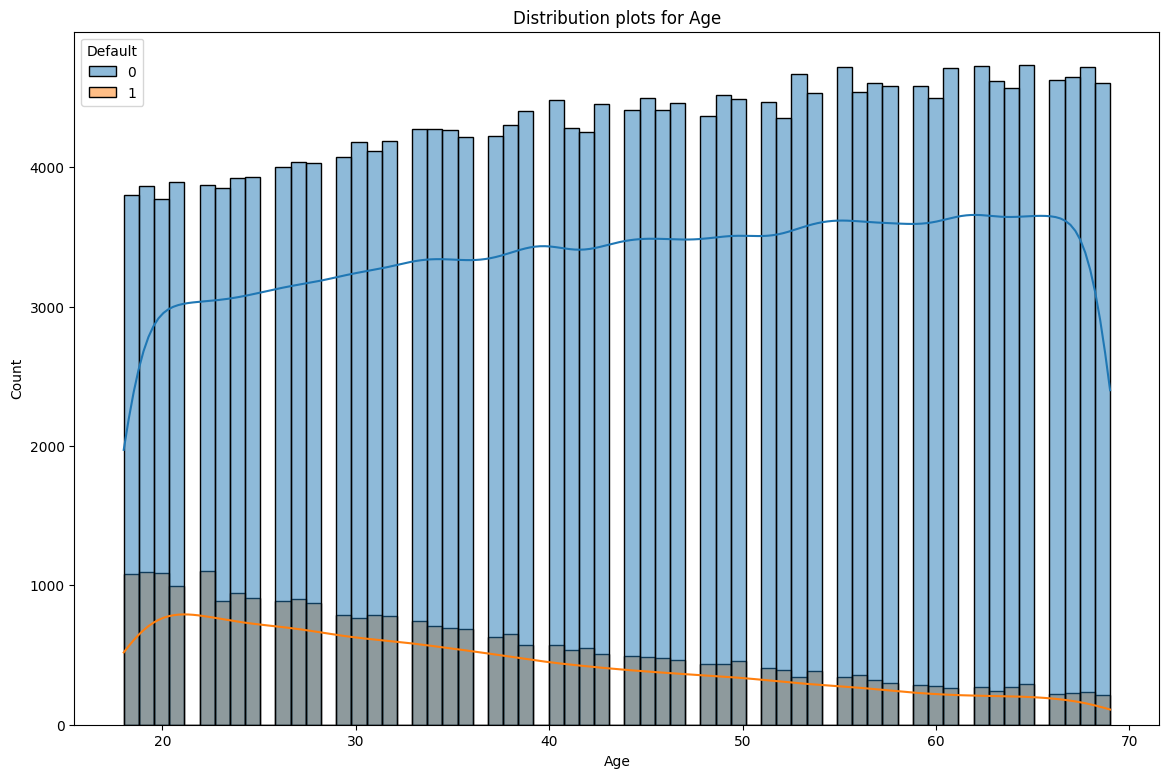

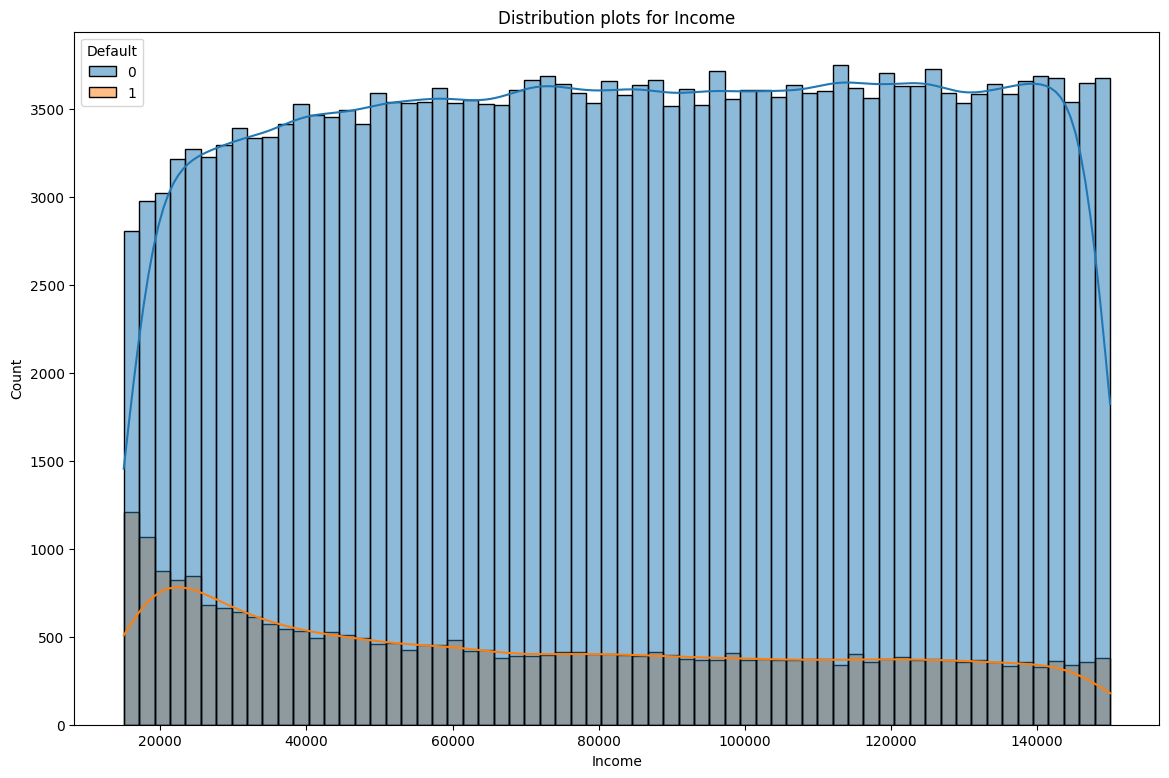

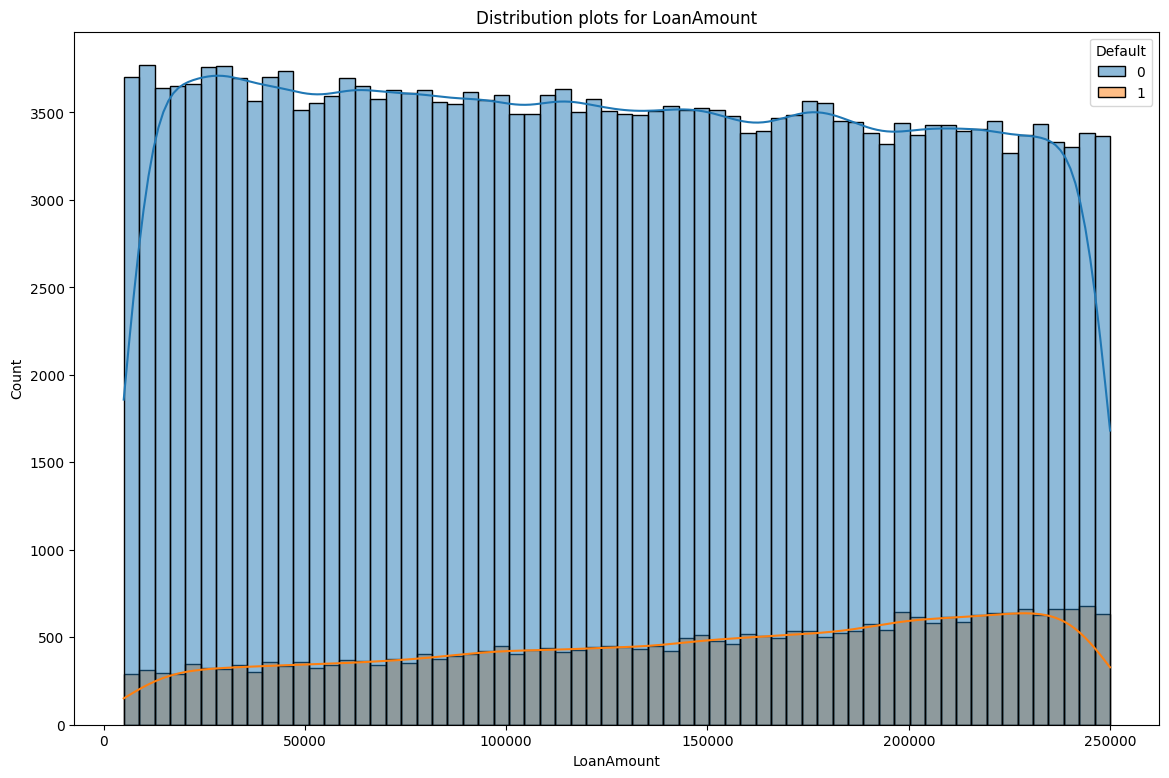

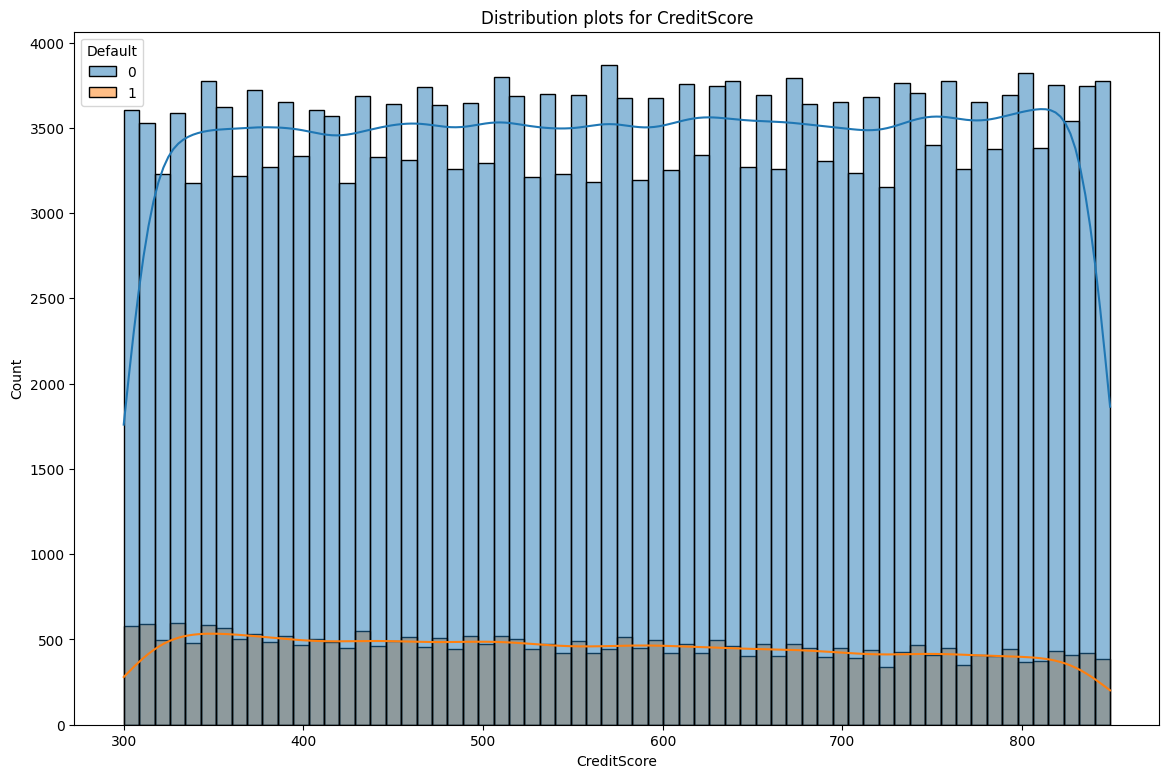

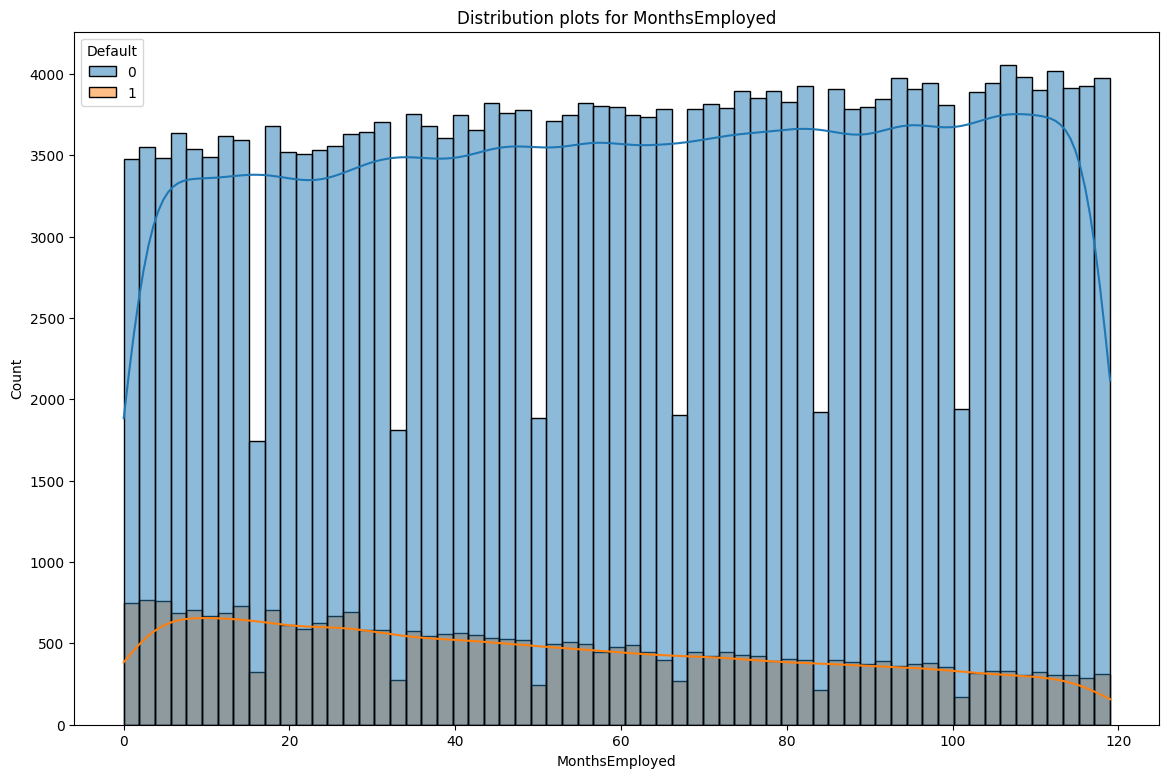

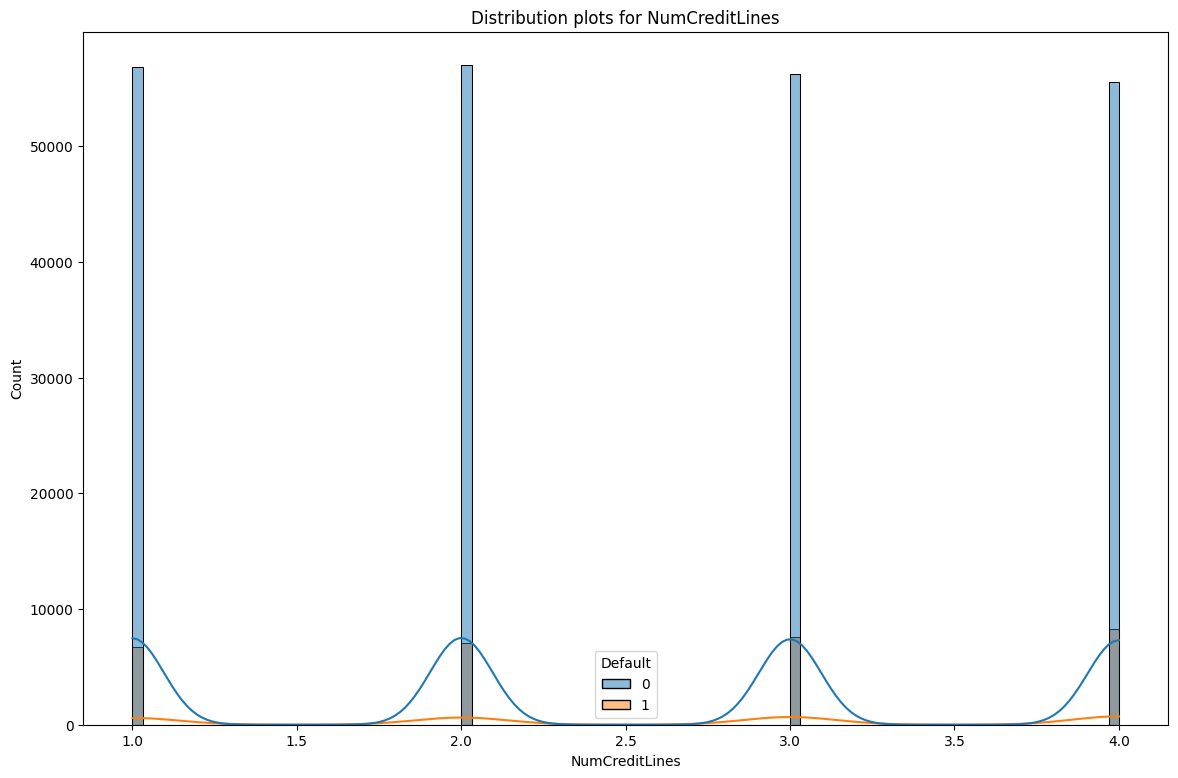

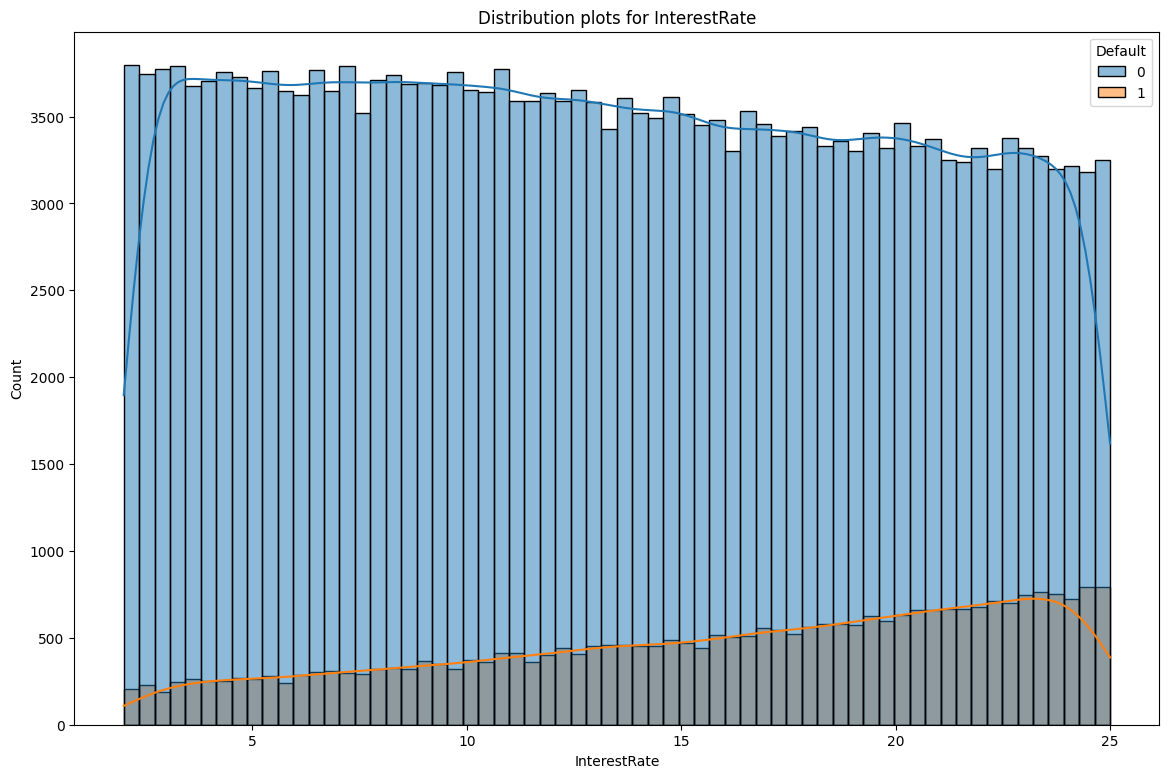

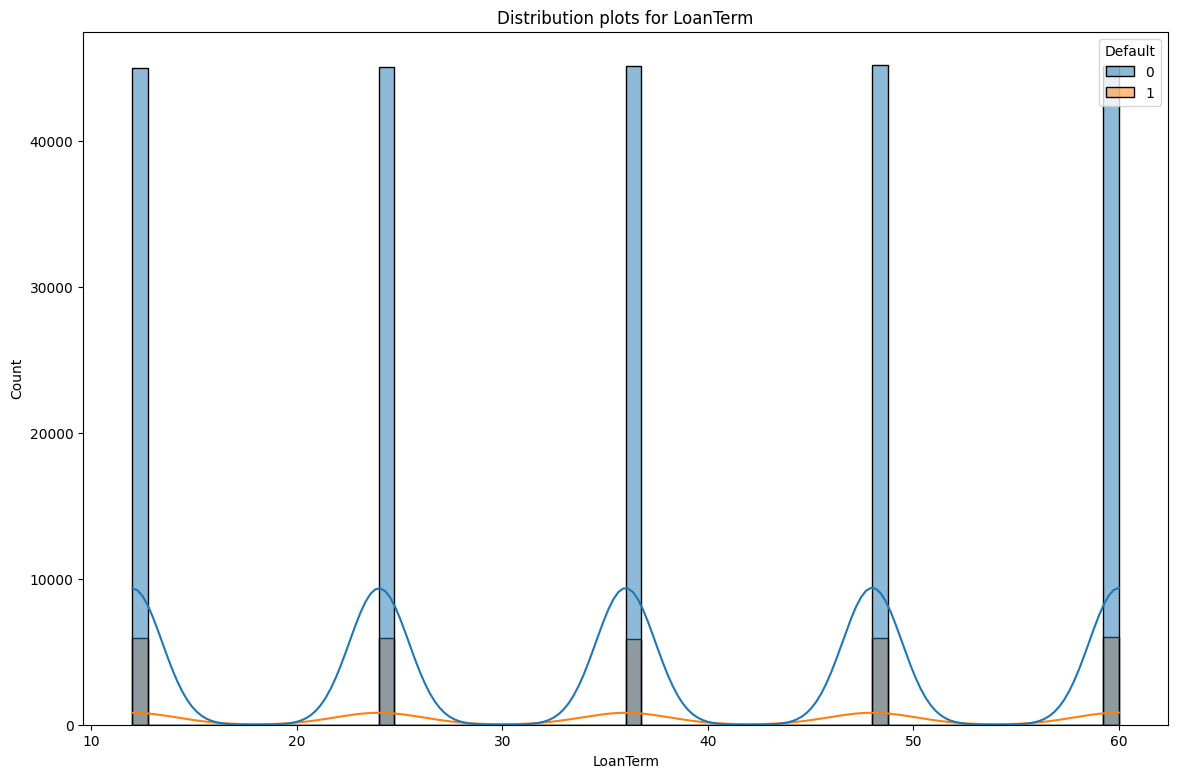

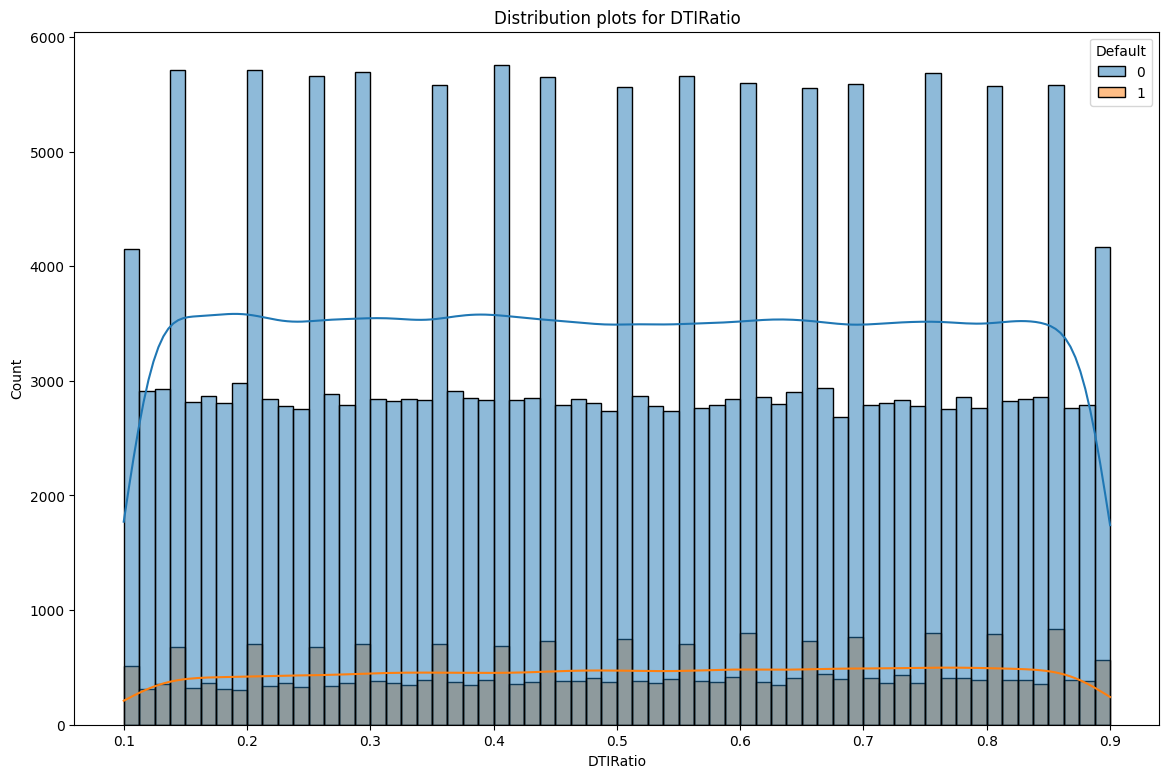

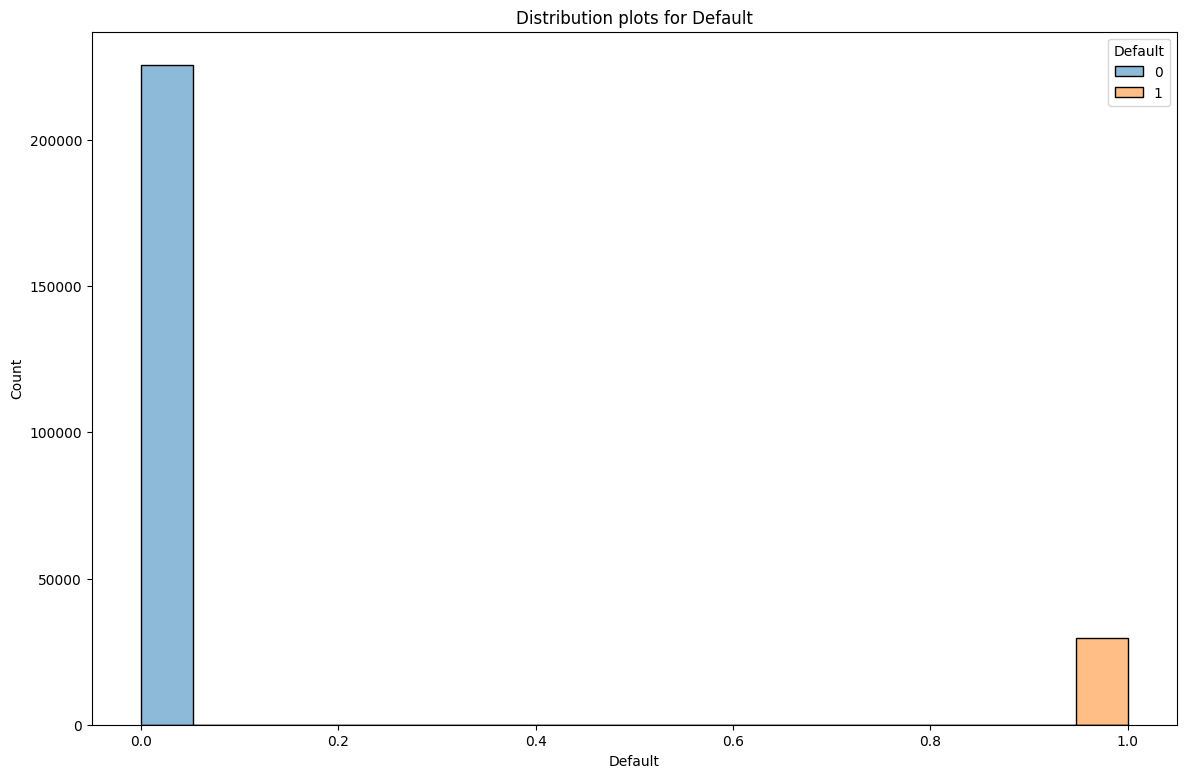

In [56]:
for col in num_cols:
    plt.figure(figsize=(14, 9))
    sns.histplot(data=df, x=col, hue='Default', kde=True)
    plt.title(f'Distribution plots for {col}')
    plt.show()

# End-to-End Data Analysis of Loan default
### 1) Loan default data is imbalanced, with majority of the cases inclined towards non-defaulters (class 0) with 88%, whereas as there are only 12% defaulters (class 1) observed in the data
### 2) Out of 255,347 borrowers, around 225,694 are considered non-defaulters, whereas 29,653 are considered defaulters.
### 3) As per the Income class, lower-income borrowers have higher default rates around 17-18%
### 4) As per the Credit Score class, borrowers with lower credit scores have more missed installments, and hence, the default rate is higher.
### 5) The age class shows that the higher age people are more mature with their decisions, having the lower default rate (< 8%)
### 6) The Loan Amount section is also categorized as lower, lower-middle, upper-middle, and higher. The loan default rate is significantly lower than higher loan amounts.
### 7) The interest rate is directly proportional to the loan default rate. The higher the interest rate, the higher the loan default rate.
### 8) The borrowers who are safe with their jobs have the lower loan default rate. Those who left the job or are unemployed are facing difficulties in clearing the installments on time.
### 9) The most affecting features for the loan default rates are the following:
### 1) Age 2) Income 3) Months Employed 4) Loan Amount 5) Interest Rate 6) Employment Type 7) Credit Score